# House Price Modeling Notebook

Notebook này được tổ chức lại để giải quyết đầy đủ các mục tiêu sau:
- Phân tích cột bị mất cân bằng và phân phối của biến mục tiêu `price`.
- So sánh nhiều chiến lược cross-validation khác nhau thay vì chỉ dùng một kiểu `KFold`.
- Bổ sung chỉ số `accuracy_tol_03`, tức là dự đoán được xem là đúng nếu sai số tuyệt đối không vượt quá `±0.3`.
- Thêm một mô hình deep learning bằng PyTorch để huấn luyện dữ liệu regression.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    ShuffleSplit,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor


## 1. Cấu hình chung

Cell này chứa toàn bộ tham số điều khiển cho notebook.
Bạn có thể chỉnh nhanh số fold, kích thước sample cho advanced CV, hoặc tolerance dùng để tính accuracy.


In [ ]:
TRAIN_PATH = "train_processed.csv"
TEST_PATH = "test_processed.csv"

TARGET_COL = "price"
DROP_COLS = ["cluster"]

RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 2
SHUFFLE_TEST_SIZE = 0.20

ACCURACY_TOLERANCE = 0.3
ACCURACY_METRIC_NAME = "accuracy_tol_03"

LOW_CARDINALITY_THRESHOLD = 20
DOMINANT_RATIO_THRESHOLD = 0.70
TARGET_BIN_COUNT = 10

USE_SAMPLE_FOR_ADVANCED_CV = True
ADVANCED_CV_SAMPLE_SIZE = 200000
ADVANCED_CV_TOP_N = 4

TORCH_EPOCHS = 25
TORCH_BATCH_SIZE = 4096
TORCH_PATIENCE = 5
TORCH_LEARNING_RATE = 1e-3
TORCH_MAX_TRAIN_SAMPLES = 250000


## 2. Nạp dữ liệu gốc

Ở đây mình đọc cả `train_processed.csv` và `test_processed.csv`.
Đồng thời giữ lại bản raw để có thể phân tích mất cân bằng trước khi loại bỏ các cột không dùng cho modeling.


In [ ]:
train_raw_df = pd.read_csv(TRAIN_PATH)
test_raw_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_raw_df.shape)
print("Test shape :", test_raw_df.shape)


Train shape: (1033064, 13)
Test shape : (258266, 13)


## 3. Kiểm tra nhanh cấu trúc dữ liệu

Cell này giúp nhìn nhanh tên cột và thống kê mô tả của biến mục tiêu `price`.
Bước này hữu ích để hiểu mức độ phân tán ban đầu của dữ liệu trước khi train mô hình.


In [ ]:
print("Train columns:")
print(train_raw_df.columns.tolist())

print("\nTarget summary:")
print(train_raw_df[TARGET_COL].describe())


Train columns:
['area', 'floor_area', 'frontage', 'house_age', 'coverage', 'Year', 'Migration', 'AverageTimeToStation', 'MunicipalityCategory', 'density', 'region_price_mean', 'cluster', 'price']

Target summary:
count    1.033064e+06
mean     1.679255e+01
std      9.298156e-01
min      5.017280e+00
25%      1.638046e+01
50%      1.703439e+01
75%      1.739903e+01
max      1.895131e+01
Name: price, dtype: float64


## 4. Phát hiện cột bị mất cân bằng

Vì đây là bài toán regression, mất cân bằng thường đáng quan tâm ở hai nơi:
- Các feature có ít mức giá trị nhưng một giá trị chiếm tỷ lệ áp đảo.
- Phân phối của `price` bị lệch mạnh khiến các khoảng giá hiếm khó được học tốt.

Cell này sẽ tự động tìm cột categorical-like bị lệch và đồng thời phân tích sự lệch của `price` theo các khoảng giá.


In [ ]:
def detect_low_cardinality_imbalance(df, target_col, low_cardinality_threshold=20, dominant_ratio_threshold=0.70):
    candidate_cols = [
        col for col in df.columns
        if col != target_col and df[col].nunique(dropna=False) <= low_cardinality_threshold
    ]

    rows = []
    for col in candidate_cols:
        freq = df[col].value_counts(normalize=True, dropna=False)
        if freq.empty:
            continue

        dominant_ratio = float(freq.iloc[0])
        rarest_ratio = float(freq.iloc[-1])
        imbalance_ratio = float(dominant_ratio / max(rarest_ratio, 1e-12))

        rows.append({
            "column": col,
            "n_unique": int(df[col].nunique(dropna=False)),
            "dominant_value": freq.index[0],
            "dominant_ratio": dominant_ratio,
            "rarest_ratio": rarest_ratio,
            "imbalance_ratio": imbalance_ratio,
            "is_imbalanced": dominant_ratio >= dominant_ratio_threshold,
        })

    result = pd.DataFrame(rows)
    if not result.empty:
        result = result.sort_values(
            ["is_imbalanced", "dominant_ratio", "imbalance_ratio"],
            ascending=[False, False, False],
        ).reset_index(drop=True)
    return result


def summarize_target_distribution(y, bins=10):
    binned = pd.cut(y, bins=bins, include_lowest=True)
    counts = binned.value_counts().sort_index()

    summary = pd.DataFrame({
        "price_bin": counts.index.astype(str),
        "count": counts.values,
    })
    summary["ratio"] = summary["count"] / summary["count"].sum()

    nonzero_counts = summary.loc[summary["count"] > 0, "count"]
    imbalance_ratio = float(nonzero_counts.max() / nonzero_counts.min()) if len(nonzero_counts) > 1 else 1.0
    skewness = float(pd.Series(y).skew())
    return summary, skewness, imbalance_ratio


feature_imbalance_df = detect_low_cardinality_imbalance(
    train_raw_df,
    target_col=TARGET_COL,
    low_cardinality_threshold=LOW_CARDINALITY_THRESHOLD,
    dominant_ratio_threshold=DOMINANT_RATIO_THRESHOLD,
)

target_bin_df, target_skewness, target_imbalance_ratio = summarize_target_distribution(
    train_raw_df[TARGET_COL],
    bins=TARGET_BIN_COUNT,
)

if feature_imbalance_df.empty:
    print("Không tìm thấy cột low-cardinality để kiểm tra mất cân bằng theo ngưỡng hiện tại.")
else:
    print("Top feature categorical-like có dấu hiệu mất cân bằng:")
    display(feature_imbalance_df.head(10))

print("\nPhân phối price theo equal-width bins:")
display(target_bin_df)

if not feature_imbalance_df.empty and feature_imbalance_df["is_imbalanced"].any():
    strongest_feature = feature_imbalance_df.loc[feature_imbalance_df["is_imbalanced"]].iloc[0]
    print(
        f"Cột feature mất cân bằng mạnh nhất: {strongest_feature['column']} | "
        f"dominant_ratio={strongest_feature['dominant_ratio']:.2%}"
    )
else:
    print("Không có feature categorical-like nào vượt ngưỡng dominant_ratio đã đặt.")

print(f"Target price skewness: {target_skewness:.3f}")
print(f"Target imbalance ratio theo equal-width bins: {target_imbalance_ratio:.2f}")

print("\nĐề xuất hướng xử lý:")
print("- Dùng StratifiedKFold trên price đã binning để giữ phân phối giá ổn định giữa các fold.")
print("- Nếu price lệch phải mạnh, cân nhắc log1p(price) hoặc sample_weight cho các vùng giá hiếm.")
print("- Nếu feature categorical-like quá lệch, cân nhắc gộp nhóm hiếm hoặc dùng frequency/target encoding.")


Top feature categorical-like có dấu hiệu mất cân bằng:


,column,n_unique,dominant_value,dominant_ratio,rarest_ratio,imbalance_ratio,is_imbalanced
0,coverage,6,0.000000,0.628644,0.003118,201.623719,False
1,MunicipalityCategory,4,0.000000,0.607220,0.001659,365.984247,False
2,region_price_mean,4,0.000000,0.607220,0.001659,365.984247,False
3,cluster,5,-1.000000,0.328766,0.022451,14.643901,False
4,Year,20,0.555556,0.067485,0.004198,16.074706,False



Phân phối price theo equal-width bins:


,price_bin,count,ratio
0,"(5.002, 6.411]",17,0.000016
1,"(6.411, 7.804]",42,0.000041
2,"(7.804, 9.197]",19,0.000018
3,"(9.197, 10.591]",209,0.000202
4,"(10.591, 11.984]",825,0.000799
5,"(11.984, 13.378]",4261,0.004125
6,"(13.378, 14.771]",30970,0.029979
7,"(14.771, 16.165]",180597,0.174817
8,"(16.165, 17.558]",654137,0.633201
9,"(17.558, 18.951]",161987,0.156802


Không có feature categorical-like nào vượt ngưỡng dominant_ratio đã đặt.
Target price skewness: -1.369
Target imbalance ratio theo equal-width bins: 38478.65

Đề xuất hướng xử lý:
- Dùng StratifiedKFold trên price đã binning để giữ phân phối giá ổn định giữa các fold.
- Nếu price lệch phải mạnh, cân nhắc log1p(price) hoặc sample_weight cho các vùng giá hiếm.
- Nếu feature categorical-like quá lệch, cân nhắc gộp nhóm hiếm hoặc dùng frequency/target encoding.


## 5. Chuẩn bị tập train/test cho modeling

Từ bước này trở đi loại bỏ cột `cluster` khỏi pipeline chính giống notebook ban đầu.
Sau đó tách rõ `X_train`, `y_train`, `X_test`, `y_test` để mọi mô hình dùng cùng một chuẩn đầu vào.


In [ ]:
train_df = train_raw_df.drop(columns=DROP_COLS, errors="ignore").copy()
test_df = test_raw_df.drop(columns=DROP_COLS, errors="ignore").copy()

X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[TARGET_COL].copy()

X_test = test_df.drop(columns=[TARGET_COL]).copy()
y_test = test_df[TARGET_COL].copy()

print("Dropped columns:", DROP_COLS)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


Dropped columns: ['cluster']
X_train: (1033064, 11)
y_train: (1033064,)
X_test : (258266, 11)
y_test : (258266,)


## 6. Hàm tiện ích cho metric và cross-validation

Cell này gom toàn bộ hàm dùng lại nhiều lần.
Trong đó có metric mới `accuracy_tol_03`, tức là tỷ lệ dự đoán có sai số tuyệt đối nhỏ hơn hoặc bằng `0.3`.


In [ ]:
def make_price_strata(y, n_bins=10):
    y_series = pd.Series(y).reset_index(drop=True)
    unique_values = y_series.nunique()
    effective_bins = min(n_bins, unique_values)

    if effective_bins < 2:
        return np.zeros(len(y_series), dtype=int)

    ranked = y_series.rank(method="first")
    strata = pd.qcut(ranked, q=effective_bins, labels=False, duplicates="drop")
    return np.asarray(strata, dtype=int)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def tolerance_accuracy(y_true, y_pred, tolerance=0.3):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= tolerance))


def evaluate_on_test(model, X_train, y_train, X_test, y_test, tolerance=0.3):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "train_rmse": rmse(y_train, train_pred),
        "test_rmse": rmse(y_test, test_pred),
        "train_mae": mean_absolute_error(y_train, train_pred),
        "test_mae": mean_absolute_error(y_test, test_pred),
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred),
        f"train_{ACCURACY_METRIC_NAME}": tolerance_accuracy(y_train, train_pred, tolerance=tolerance),
        f"test_{ACCURACY_METRIC_NAME}": tolerance_accuracy(y_test, test_pred, tolerance=tolerance),
    }


def build_cv_strategies(X, y, n_splits=5, n_repeats=2, shuffle_test_size=0.2, random_state=42, target_bins=10):
    strata = make_price_strata(y, n_bins=target_bins)

    strategies = {
        "KFold": KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        "RepeatedKFold": RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state),
        "ShuffleSplit": ShuffleSplit(n_splits=n_splits, test_size=shuffle_test_size, random_state=random_state),
    }

    if len(np.unique(strata)) >= 2:
        stratified_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        strategies["StratifiedKFold(price_bin)"] = list(stratified_cv.split(X, strata))

    return strategies


## 7. Lấy sample riêng cho advanced CV

Nhiều chiến lược CV trên tập hơn 1 triệu dòng sẽ rất tốn thời gian, đặc biệt với tree ensemble và PyTorch.
Vì vậy mình tách riêng một sample cho phần advanced CV để so sánh chiến lược đánh giá nhanh hơn nhưng vẫn đủ lớn để quan sát xu hướng.


In [ ]:
if USE_SAMPLE_FOR_ADVANCED_CV and len(X_train) > ADVANCED_CV_SAMPLE_SIZE:
    cv_sample_idx = X_train.sample(ADVANCED_CV_SAMPLE_SIZE, random_state=RANDOM_STATE).index
    X_cv = X_train.loc[cv_sample_idx].copy()
    y_cv = y_train.loc[cv_sample_idx].copy()
    print(f"Using sample for advanced CV: {X_cv.shape}")
else:
    X_cv = X_train.copy()
    y_cv = y_train.copy()
    print(f"Using full train set for advanced CV: {X_cv.shape}")


Using sample for advanced CV: (200000, 11)


## 8. Khởi tạo các mô hình machine learning truyền thống

Đây là nhóm mô hình nền để so sánh với deep learning.
Mình giữ phần lớn cấu hình từ notebook cũ để kết quả mới vẫn còn tính liên tục với phần trước đó.


In [ ]:
models = {
    "LinearRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),

    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005)),
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),

    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=150,
            max_depth=20,
            min_samples_split=4,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),

    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_STATE,
        )),
    ]),
}

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    print("XGBoost added.")
except Exception as exc:
    print(f"XGBoost not available: {exc}")


XGBoost added.


## 9. Định nghĩa mô hình deep learning bằng PyTorch

Mô hình dưới đây là một MLP regression nhiều tầng ẩn, có dropout và early stopping.
Mình viết theo giao diện estimator của scikit-learn để có thể đưa vào `Pipeline` và `cross_validate` giống các model còn lại.


In [ ]:
class TorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        hidden_dims=(128, 64),
        dropout=0.10,
        lr=1e-3,
        batch_size=4096,
        epochs=25,
        patience=5,
        validation_fraction=0.10,
        random_state=42,
        device=None,
        max_train_samples=250000,
        verbose=False,
    ):
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.validation_fraction = validation_fraction
        self.random_state = random_state
        self.device = device
        self.max_train_samples = max_train_samples
        self.verbose = verbose

    def _build_network(self, input_dim):
        import torch
        import torch.nn as nn

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(self.dropout),
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        return nn.Sequential(*layers)

    def fit(self, X, y):
        import torch
        import torch.nn as nn
        from torch.utils.data import DataLoader, TensorDataset

        X_np = np.asarray(X, dtype=np.float32)
        y_np = np.asarray(y, dtype=np.float32).reshape(-1, 1)

        random.seed(self.random_state)
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.random_state)

        if self.max_train_samples is not None and len(X_np) > self.max_train_samples:
            rng = np.random.RandomState(self.random_state)
            sample_idx = rng.choice(len(X_np), size=self.max_train_samples, replace=False)
            X_np = X_np[sample_idx]
            y_np = y_np[sample_idx]

        if self.validation_fraction and len(X_np) >= 1000:
            X_fit, X_val, y_fit, y_val = train_test_split(
                X_np,
                y_np,
                test_size=self.validation_fraction,
                random_state=self.random_state,
            )
        else:
            X_fit, y_fit = X_np, y_np
            X_val, y_val = None, None

        self.device_ = torch.device(self.device or ("cuda" if torch.cuda.is_available() else "cpu"))
        self.model_ = self._build_network(X_np.shape[1]).to(self.device_)
        self.n_features_in_ = X_np.shape[1]

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=1e-4)
        loss_fn = nn.MSELoss()

        train_dataset = TensorDataset(torch.from_numpy(X_fit), torch.from_numpy(y_fit))
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        has_val = X_val is not None and y_val is not None and len(X_val) > 0
        if has_val:
            val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        best_state = None
        best_val_loss = np.inf
        patience_counter = 0

        for epoch in range(self.epochs):
            self.model_.train()
            train_losses = []

            for xb, yb in train_loader:
                xb = xb.to(self.device_)
                yb = yb.to(self.device_)

                optimizer.zero_grad()
                pred = self.model_(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                optimizer.step()

                train_losses.append(loss.item())

            if has_val:
                self.model_.eval()
                val_losses = []
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb = xb.to(self.device_)
                        yb = yb.to(self.device_)
                        pred = self.model_(xb)
                        val_loss = loss_fn(pred, yb)
                        val_losses.append(val_loss.item())

                mean_val_loss = float(np.mean(val_losses))
                if mean_val_loss < best_val_loss - 1e-6:
                    best_val_loss = mean_val_loss
                    best_state = copy.deepcopy(self.model_.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= self.patience:
                        break

            if self.verbose:
                mean_train_loss = float(np.mean(train_losses)) if train_losses else np.nan
                if has_val:
                    print(f"Epoch {epoch + 1}/{self.epochs} - train_loss={mean_train_loss:.5f} - val_loss={mean_val_loss:.5f}")
                else:
                    print(f"Epoch {epoch + 1}/{self.epochs} - train_loss={mean_train_loss:.5f}")

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        return self

    def predict(self, X):
        import torch
        from torch.utils.data import DataLoader, TensorDataset

        X_np = np.asarray(X, dtype=np.float32)
        pred_dataset = TensorDataset(torch.from_numpy(X_np))
        pred_loader = DataLoader(pred_dataset, batch_size=self.batch_size, shuffle=False)

        preds = []
        self.model_.eval()
        with torch.no_grad():
            for (xb,) in pred_loader:
                xb = xb.to(self.device_)
                pred = self.model_(xb).cpu().numpy().reshape(-1)
                preds.append(pred)

        return np.concatenate(preds)


## 10. Đưa PyTorch vào tập mô hình so sánh

Nếu môi trường có cài `torch`, model deep learning sẽ được thêm vào dictionary `models`.
Nếu chưa có thư viện này, notebook vẫn chạy các model còn lại bình thường.


In [ ]:
try:
    import torch

    models["PyTorchMLP"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", TorchRegressor(
            hidden_dims=(128, 64),
            dropout=0.10,
            lr=TORCH_LEARNING_RATE,
            batch_size=TORCH_BATCH_SIZE,
            epochs=TORCH_EPOCHS,
            patience=TORCH_PATIENCE,
            validation_fraction=0.10,
            random_state=RANDOM_STATE,
            max_train_samples=TORCH_MAX_TRAIN_SAMPLES,
            verbose=False,
        )),
    ])

    print("PyTorch version:", torch.__version__)
    print("PyTorchMLP added.")
except Exception as exc:
    print(f"PyTorch not available: {exc}")


PyTorch version: 2.10.0+cu128
PyTorchMLP added.


## 11. Đánh giá baseline trên train/test split hiện tại

Cell này train từng mô hình trên toàn bộ `X_train` rồi đo trực tiếp trên `X_test`.
Ngoài `RMSE`, `MAE`, `R2`, bảng kết quả bây giờ có thêm cột `accuracy_tol_03` như bạn yêu cầu.


In [ ]:
before_cv_results = []
baseline_errors = []

for name, model in models.items():
    print(f"Training baseline model: {name}")
    try:
        result = evaluate_on_test(
            model,
            X_train,
            y_train,
            X_test,
            y_test,
            tolerance=ACCURACY_TOLERANCE,
        )
        result["model"] = name
        before_cv_results.append(result)
    except Exception as exc:
        print(f"Skipped baseline model {name}: {exc}")
        baseline_errors.append({"model": name, "error": str(exc)})

if not before_cv_results:
    raise ValueError("Không có model baseline nào chạy thành công. Hãy kiểm tra lại dữ liệu sau bước làm sạch.")

before_cv_df = (
    pd.DataFrame(before_cv_results)
    .sort_values(["test_rmse", "test_mae", f"test_{ACCURACY_METRIC_NAME}"], ascending=[True, True, False])
    .reset_index(drop=True)
)

display(before_cv_df)

if baseline_errors:
    print("\nBaseline models bị bỏ qua:")
    display(pd.DataFrame(baseline_errors))

Training baseline model: LinearRegression
Training baseline model: Ridge
Training baseline model: Lasso
Training baseline model: RandomForest
Training baseline model: ExtraTrees
Training baseline model: GradientBoosting
Training baseline model: XGBoost
Training baseline model: PyTorchMLP


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,train_accuracy_tol_03,test_accuracy_tol_03,model
0,0.412505,0.522519,0.278371,0.347577,0.803182,0.682781,0.677128,0.599440,ExtraTrees
1,0.424042,0.524408,0.285321,0.347578,0.792019,0.680483,0.670739,0.602274,RandomForest
2,0.522679,0.525271,0.350447,0.352671,0.684007,0.679431,0.590609,0.589044,XGBoost
3,0.540458,0.538794,0.364203,0.364410,0.662145,0.662713,0.572759,0.572631,GradientBoosting
4,0.549904,0.547182,0.374328,0.373919,0.650232,0.652129,0.557141,0.556403,PyTorchMLP
5,0.591311,0.589084,0.407446,0.407258,0.595574,0.596810,0.514829,0.514605,Ridge
6,0.591311,0.589084,0.407447,0.407259,0.595574,0.596810,0.514825,0.514609,LinearRegression
7,0.591466,0.589239,0.407136,0.406929,0.595362,0.596598,0.515888,0.515658,Lasso


## 12. So sánh nhiều chiến lược cross-validation

 `KFold`,`RepeatedKFold`, `ShuffleSplit`, và `StratifiedKFold(price_bin)` để xem chiến lược nào cho validation ổn định hơn trên dữ liệu regression bị lệch phân phối.


In [ ]:
cv_strategies = build_cv_strategies(
    X_cv,
    y_cv,
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    shuffle_test_size=SHUFFLE_TEST_SIZE,
    random_state=RANDOM_STATE,
    target_bins=TARGET_BIN_COUNT,
)

selected_model_names = before_cv_df.nsmallest(ADVANCED_CV_TOP_N, "test_rmse")["model"].tolist()
if "PyTorchMLP" in models and "PyTorchMLP" not in selected_model_names:
    selected_model_names.append("PyTorchMLP")

selected_model_names = [name for name in selected_model_names if name in models]
print("Models selected for advanced CV:", selected_model_names)
print("CV strategies:", list(cv_strategies.keys()))

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
    ACCURACY_METRIC_NAME: make_scorer(tolerance_accuracy, tolerance=ACCURACY_TOLERANCE),
}

advanced_cv_results = []

for strategy_name, cv in cv_strategies.items():
    for model_name in selected_model_names:
        model = models[model_name]
        print(f"Cross-validating {model_name} with {strategy_name}")

        try:
            scores = cross_validate(
                model,
                X_cv,
                y_cv,
                cv=cv,
                scoring=scoring,
                return_train_score=True,
                n_jobs=1,
                error_score="raise",
            )

            advanced_cv_results.append({
                "cv_strategy": strategy_name,
                "model": model_name,
                "cv_train_rmse": -scores["train_rmse"].mean(),
                "cv_val_rmse": -scores["test_rmse"].mean(),
                "cv_train_mae": -scores["train_mae"].mean(),
                "cv_val_mae": -scores["test_mae"].mean(),
                "cv_train_r2": scores["train_r2"].mean(),
                "cv_val_r2": scores["test_r2"].mean(),
                f"cv_train_{ACCURACY_METRIC_NAME}": scores[f"train_{ACCURACY_METRIC_NAME}"].mean(),
                f"cv_val_{ACCURACY_METRIC_NAME}": scores[f"test_{ACCURACY_METRIC_NAME}"].mean(),
            })
        except Exception as exc:
            print(f"Skipped {model_name} with {strategy_name}: {exc}")

advanced_cv_df = pd.DataFrame(advanced_cv_results)
if not advanced_cv_df.empty:
    advanced_cv_df = advanced_cv_df.sort_values(
        ["cv_val_rmse", "cv_val_mae", f"cv_val_{ACCURACY_METRIC_NAME}"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

display(advanced_cv_df)


Models selected for advanced CV: ['ExtraTrees', 'RandomForest', 'XGBoost', 'GradientBoosting', 'PyTorchMLP']
CV strategies: ['KFold', 'RepeatedKFold', 'ShuffleSplit', 'StratifiedKFold(price_bin)']
Cross-validating ExtraTrees with KFold
Cross-validating RandomForest with KFold
Cross-validating XGBoost with KFold
Cross-validating GradientBoosting with KFold
Cross-validating PyTorchMLP with KFold
Cross-validating ExtraTrees with RepeatedKFold
Cross-validating RandomForest with RepeatedKFold
Cross-validating XGBoost with RepeatedKFold
Cross-validating GradientBoosting with RepeatedKFold
Cross-validating PyTorchMLP with RepeatedKFold
Cross-validating ExtraTrees with ShuffleSplit
Cross-validating RandomForest with ShuffleSplit
Cross-validating XGBoost with ShuffleSplit
Cross-validating GradientBoosting with ShuffleSplit
Cross-validating PyTorchMLP with ShuffleSplit
Cross-validating ExtraTrees with StratifiedKFold(price_bin)
Cross-validating RandomForest with StratifiedKFold(price_bin)
Cross-

,cv_strategy,model,cv_train_rmse,cv_val_rmse,cv_train_mae,cv_val_mae,cv_train_r2,cv_val_r2,cv_train_accuracy_tol_03,cv_val_accuracy_tol_03
0,StratifiedKFold(price_bin),XGBoost,0.502338,0.533139,0.341771,0.356928,0.706910,0.669858,0.593932,0.583460
1,KFold,XGBoost,0.502683,0.533307,0.341848,0.357102,0.706507,0.669651,0.593914,0.582960
2,RepeatedKFold,XGBoost,0.502605,0.533354,0.341857,0.357113,0.706598,0.669585,0.593873,0.582963
3,ShuffleSplit,XGBoost,0.502156,0.534347,0.341888,0.356723,0.707083,0.668535,0.593954,0.583570
4,StratifiedKFold(price_bin),ExtraTrees,0.313283,0.536381,0.212095,0.357030,0.886003,0.665830,0.776066,0.587270
5,RepeatedKFold,ExtraTrees,0.313397,0.536457,0.212030,0.357064,0.885921,0.665727,0.776121,0.587503
6,KFold,ExtraTrees,0.313461,0.536493,0.211981,0.357081,0.885875,0.665691,0.776301,0.587500
7,ShuffleSplit,ExtraTrees,0.313573,0.537438,0.212378,0.356729,0.885778,0.664690,0.775159,0.588000
8,KFold,RandomForest,0.354713,0.542121,0.238979,0.361103,0.853861,0.658637,0.735996,0.584785
9,StratifiedKFold(price_bin),RandomForest,0.354557,0.542224,0.238863,0.361008,0.853990,0.658510,0.736123,0.584070


## 13. Tổng hợp xem chiến lược CV nào tốt hơn

Cell này gom hai góc nhìn:
- Kết quả baseline trên test set.
- Kết quả tốt nhất của từng mô hình dưới các CV strategy khác nhau.

Mục tiêu là xem model nào ổn định nhất và chiến lược validation nào cho tín hiệu đáng tin hơn.


In [ ]:
if advanced_cv_df.empty:
    summary_df = before_cv_df.copy()
    strategy_summary_df = pd.DataFrame()
    print("Chưa có kết quả advanced CV để tổng hợp.")
else:
    best_cv_by_model = (
        advanced_cv_df
        .sort_values(["cv_val_rmse", "cv_val_mae", f"cv_val_{ACCURACY_METRIC_NAME}"], ascending=[True, True, False])
        .drop_duplicates("model")
        .rename(columns={
            "cv_strategy": "best_cv_strategy",
            "cv_train_rmse": "best_cv_train_rmse",
            "cv_val_rmse": "best_cv_val_rmse",
            "cv_train_mae": "best_cv_train_mae",
            "cv_val_mae": "best_cv_val_mae",
            "cv_train_r2": "best_cv_train_r2",
            "cv_val_r2": "best_cv_val_r2",
            f"cv_train_{ACCURACY_METRIC_NAME}": f"best_cv_train_{ACCURACY_METRIC_NAME}",
            f"cv_val_{ACCURACY_METRIC_NAME}": f"best_cv_val_{ACCURACY_METRIC_NAME}",
        })
        .reset_index(drop=True)
    )

    summary_df = before_cv_df.merge(best_cv_by_model, on="model", how="left")
    summary_df["rmse_gap_test_minus_best_cv"] = summary_df["test_rmse"] - summary_df["best_cv_val_rmse"]
    summary_df["mae_gap_test_minus_best_cv"] = summary_df["test_mae"] - summary_df["best_cv_val_mae"]
    summary_df["acc_gap_test_minus_best_cv"] = (
        summary_df[f"test_{ACCURACY_METRIC_NAME}"] - summary_df[f"best_cv_val_{ACCURACY_METRIC_NAME}"]
    )
    summary_df = summary_df.sort_values(
        ["best_cv_val_rmse", "test_rmse", f"test_{ACCURACY_METRIC_NAME}"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    strategy_summary_df = (
        advanced_cv_df
        .groupby("cv_strategy", as_index=False)
        .agg(
            mean_val_rmse=("cv_val_rmse", "mean"),
            mean_val_mae=("cv_val_mae", "mean"),
            mean_val_r2=("cv_val_r2", "mean"),
            mean_val_accuracy_tol_03=(f"cv_val_{ACCURACY_METRIC_NAME}", "mean"),
        )
        .sort_values(["mean_val_rmse", "mean_val_mae", "mean_val_accuracy_tol_03"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

print("Summary by model:")
display(summary_df)

if not strategy_summary_df.empty:
    print("\nAverage validation quality by CV strategy:")
    display(strategy_summary_df)


Summary by model:


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,train_accuracy_tol_03,test_accuracy_tol_03,model,best_cv_strategy,...,best_cv_val_rmse,best_cv_train_mae,best_cv_val_mae,best_cv_train_r2,best_cv_val_r2,best_cv_train_accuracy_tol_03,best_cv_val_accuracy_tol_03,rmse_gap_test_minus_best_cv,mae_gap_test_minus_best_cv,acc_gap_test_minus_best_cv
0,0.522679,0.525271,0.350447,0.352671,0.684007,0.679431,0.590609,0.589044,XGBoost,StratifiedKFold(price_bin),...,0.533139,0.341771,0.356928,0.706910,0.669858,0.593932,0.583460,-0.007868,-0.004257,0.005584
1,0.412505,0.522519,0.278371,0.347577,0.803182,0.682781,0.677128,0.599440,ExtraTrees,StratifiedKFold(price_bin),...,0.536381,0.212095,0.357030,0.886003,0.665830,0.776066,0.587270,-0.013862,-0.009453,0.012170
2,0.424042,0.524408,0.285321,0.347578,0.792019,0.680483,0.670739,0.602274,RandomForest,KFold,...,0.542121,0.238979,0.361103,0.853861,0.658637,0.735996,0.584785,-0.017713,-0.013525,0.017489
3,0.540458,0.538794,0.364203,0.364410,0.662145,0.662713,0.572759,0.572631,GradientBoosting,StratifiedKFold(price_bin),...,0.543151,0.362032,0.366017,0.666963,0.657342,0.573398,0.570250,-0.004357,-0.001607,0.002381
4,0.549904,0.547182,0.374328,0.373919,0.650232,0.652129,0.557141,0.556403,PyTorchMLP,StratifiedKFold(price_bin),...,0.558147,0.381800,0.383747,0.642852,0.638152,0.543660,0.542040,-0.010965,-0.009828,0.014363
5,0.591311,0.589084,0.407446,0.407258,0.595574,0.596810,0.514829,0.514605,Ridge,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.591311,0.589084,0.407447,0.407259,0.595574,0.596810,0.514825,0.514609,LinearRegression,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.591466,0.589239,0.407136,0.406929,0.595362,0.596598,0.515888,0.515658,Lasso,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Average validation quality by CV strategy:


,cv_strategy,mean_val_rmse,mean_val_mae,mean_val_r2,mean_val_accuracy_tol_03
0,StratifiedKFold(price_bin),0.542608,0.364946,0.657938,0.573418
1,KFold,0.542805,0.365150,0.657688,0.573578
2,RepeatedKFold,0.542823,0.365191,0.657659,0.573206
3,ShuffleSplit,0.543614,0.364653,0.656856,0.574394


## 14. Trực quan hóa hiệu quả của từng CV strategy

Biểu đồ bên dưới giúp nhìn nhanh model nào nhạy với cách chia fold và strategy nào thường cho metric tốt hơn.
Ở đây mình vẽ song song cả `RMSE` và `accuracy_tol_03`.


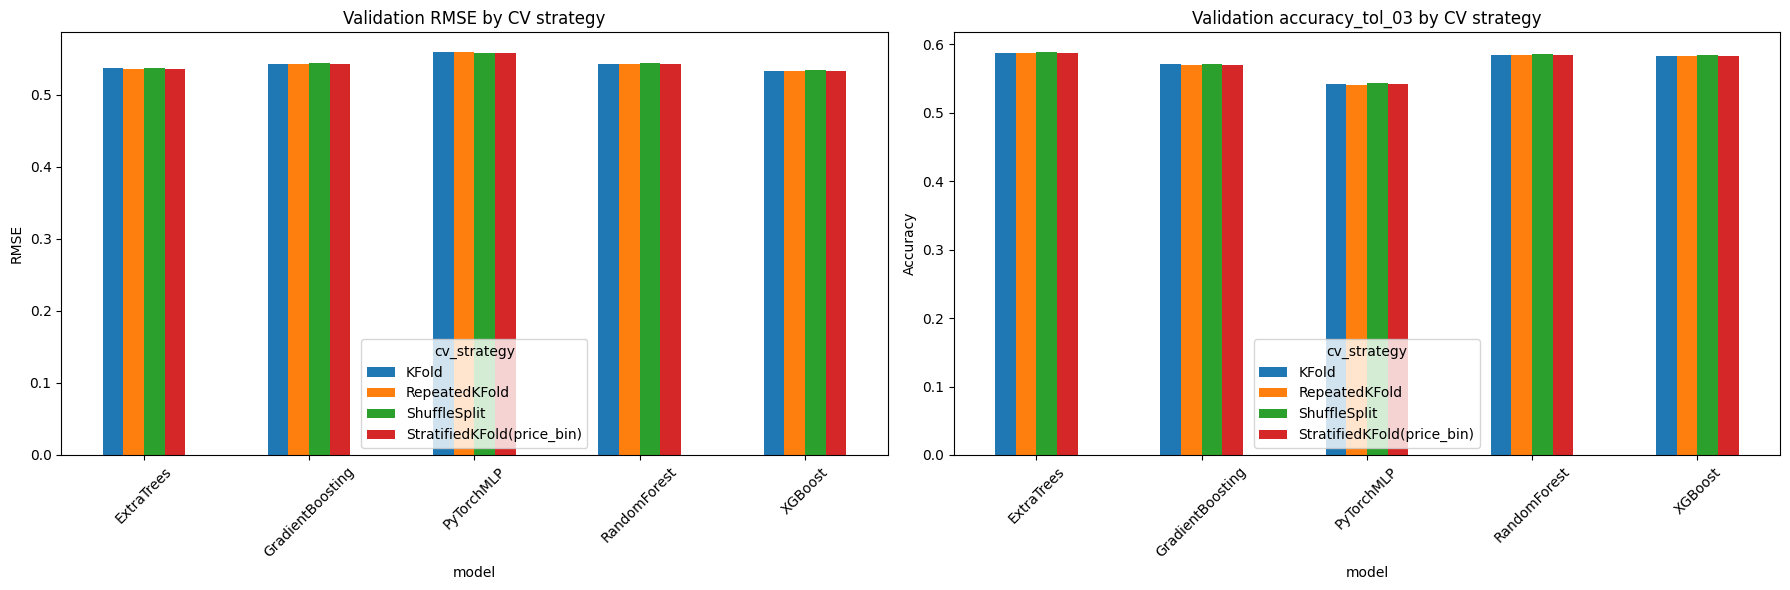

In [ ]:
if advanced_cv_df.empty:
    print("Không có kết quả advanced CV để vẽ biểu đồ.")
else:
    rmse_pivot = advanced_cv_df.pivot(index="model", columns="cv_strategy", values="cv_val_rmse")
    acc_pivot = advanced_cv_df.pivot(index="model", columns="cv_strategy", values=f"cv_val_{ACCURACY_METRIC_NAME}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    rmse_pivot.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Validation RMSE by CV strategy")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=45)

    acc_pivot.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Validation accuracy_tol_03 by CV strategy")
    axes[1].set_ylabel("Accuracy")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


## 15. Chọn mô hình cuối cùng và đánh giá lại trên test set

Nếu đã có kết quả advanced CV, mình ưu tiên chọn model có `best_cv_val_rmse` thấp nhất.
Sau đó train lại trên toàn bộ `X_train` và in đầy đủ các metric, bao gồm cả `accuracy_tol_03` và bảng dự đoán mẫu.


In [ ]:
if "best_cv_val_rmse" in summary_df.columns and summary_df["best_cv_val_rmse"].notna().any():
    best_model_name = summary_df.loc[summary_df["best_cv_val_rmse"].idxmin(), "model"]
    selection_reason = "best validation RMSE across advanced CV strategies"
else:
    best_model_name = before_cv_df.iloc[0]["model"]
    selection_reason = "best test RMSE in baseline comparison"

best_model = models[best_model_name]
print(f"Selected final model: {best_model_name} ({selection_reason})")

final_metrics = evaluate_on_test(
    best_model,
    X_train,
    y_train,
    X_test,
    y_test,
    tolerance=ACCURACY_TOLERANCE,
)

print("\nFinal Test Metrics")
for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.6f}")

best_model.fit(X_train, y_train)
final_pred = best_model.predict(X_test)

final_prediction_df = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": final_pred,
})
final_prediction_df["abs_error"] = (final_prediction_df["actual_price"] - final_prediction_df["predicted_price"]).abs()
final_prediction_df["within_tol_03"] = final_prediction_df["abs_error"] <= ACCURACY_TOLERANCE

display(final_prediction_df.head(10))
print(f"\nAccuracy within ±{ACCURACY_TOLERANCE}: {final_prediction_df['within_tol_03'].mean():.4f}")


Selected final model: XGBoost (best validation RMSE across advanced CV strategies)

Final Test Metrics
train_rmse: 0.522679
test_rmse: 0.525271
train_mae: 0.350447
test_mae: 0.352671
train_r2: 0.684007
test_r2: 0.679431
train_accuracy_tol_03: 0.590609
test_accuracy_tol_03: 0.589044


,actual_price,predicted_price,abs_error,within_tol_03
0,17.111347,17.317167,0.205820,True
1,17.576711,17.285378,0.291333,True
2,18.420681,17.959457,0.461223,False
3,16.380460,16.424059,0.043599,True
4,16.951005,16.599682,0.351323,False
5,17.182806,17.189409,0.006603,True
6,16.860033,16.300186,0.559847,False
7,16.705882,16.964499,0.258616,True
8,17.926384,17.459663,0.466721,False
9,17.216708,17.287695,0.070987,True



Accuracy within ±0.3: 0.5890


## 16. Biểu đồ so sánh hiệu năng giữa các mô hình

Cell này trực quan hóa các metric chính để nhìn nhanh model nào đang tốt hơn theo từng tiêu chí.
Nếu notebook đã có `summary_df` thì biểu đồ sẽ ưu tiên bảng tổng hợp đó; nếu chưa thì dùng `before_cv_df`.


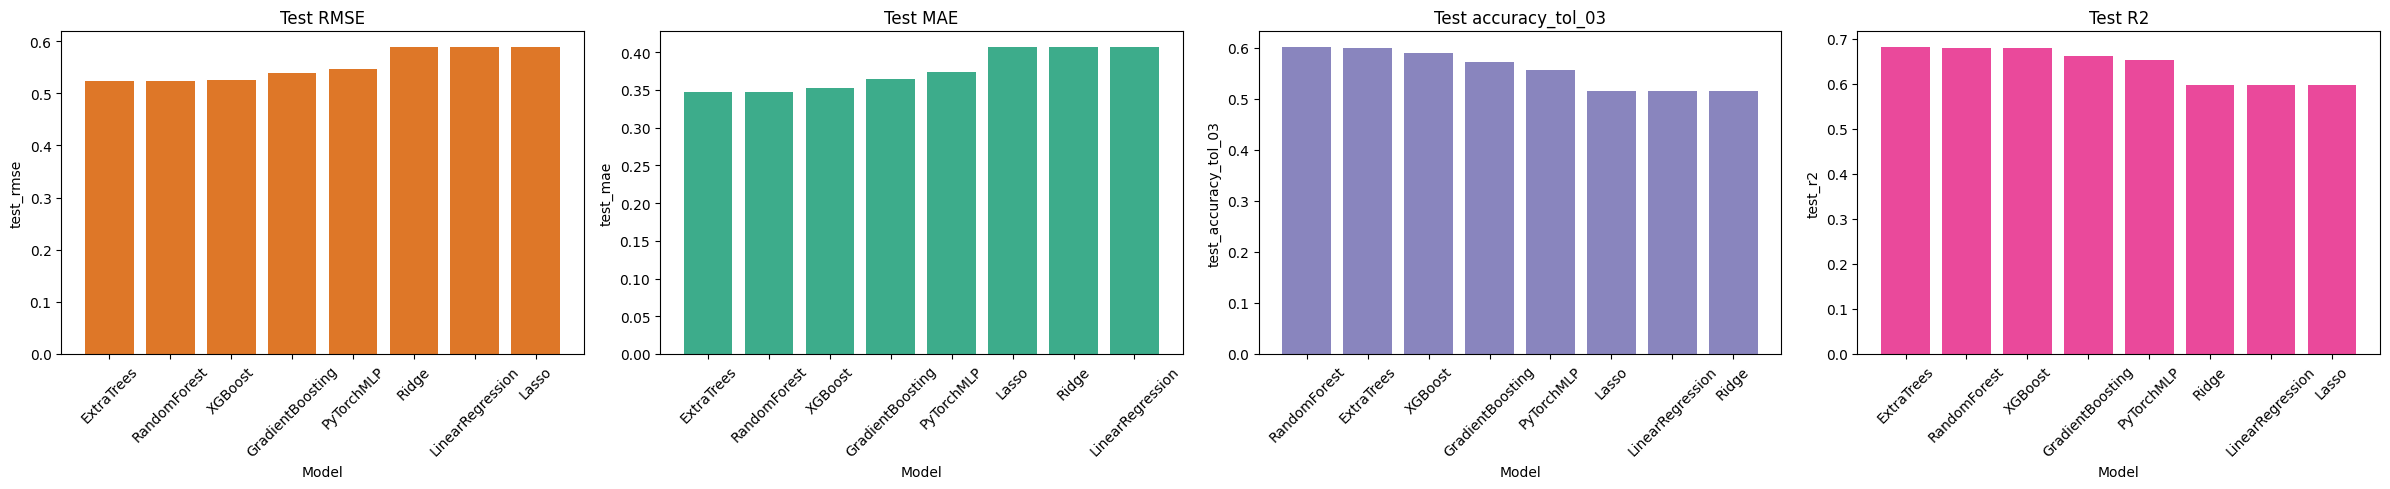

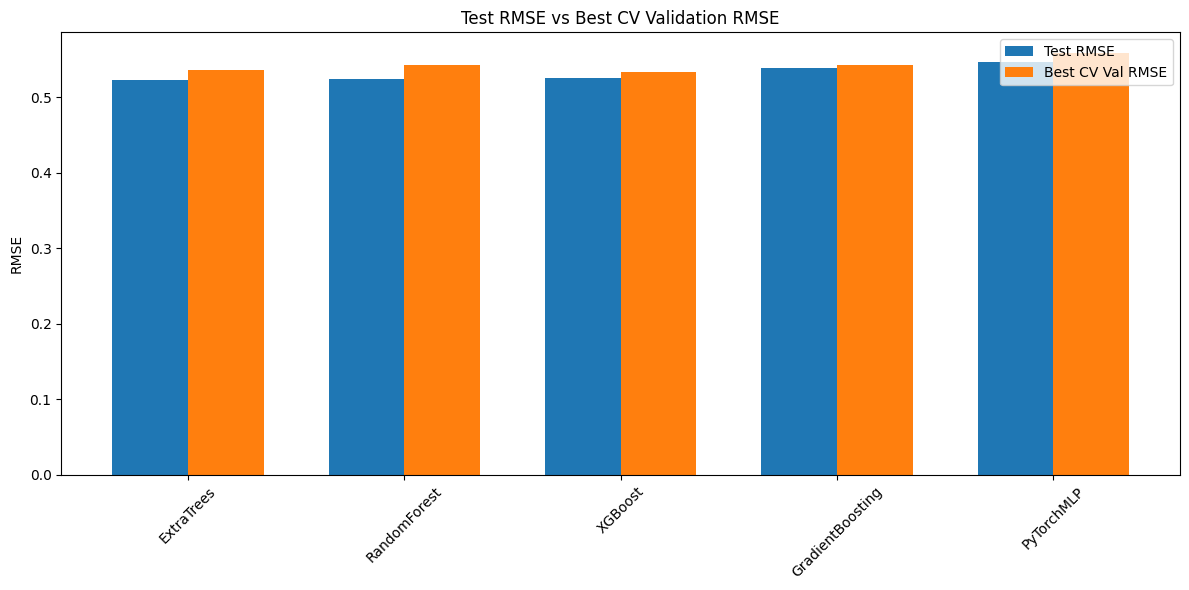

In [ ]:
plot_source_df = summary_df.copy() if "summary_df" in globals() else before_cv_df.copy()

metric_specs = [
    ("test_rmse", "Test RMSE", True, "#d95f02"),
    ("test_mae", "Test MAE", True, "#1b9e77"),
    (f"test_{ACCURACY_METRIC_NAME}", f"Test {ACCURACY_METRIC_NAME}", False, "#7570b3"),
    ("test_r2", "Test R2", False, "#e7298a"),
]

available_metric_specs = [spec for spec in metric_specs if spec[0] in plot_source_df.columns]
fig, axes = plt.subplots(1, len(available_metric_specs), figsize=(6 * len(available_metric_specs), 5))

if len(available_metric_specs) == 1:
    axes = [axes]

for ax, (metric_col, title, ascending, color) in zip(axes, available_metric_specs):
    metric_df = plot_source_df.sort_values(metric_col, ascending=ascending)
    ax.bar(metric_df["model"], metric_df[metric_col], color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

if {"test_rmse", "best_cv_val_rmse"}.issubset(plot_source_df.columns):
    compare_plot_df = (
        plot_source_df
        .dropna(subset=["best_cv_val_rmse"])
        .sort_values("test_rmse")
        .head(min(6, len(plot_source_df)))
    )

    x = np.arange(len(compare_plot_df))
    width = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(x - width / 2, compare_plot_df["test_rmse"], width, label="Test RMSE")
    plt.bar(x + width / 2, compare_plot_df["best_cv_val_rmse"], width, label="Best CV Val RMSE")
    plt.xticks(x, compare_plot_df["model"], rotation=45)
    plt.ylabel("RMSE")
    plt.title("Test RMSE vs Best CV Validation RMSE")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 17. Biểu đồ predicted price so với real price

Cell này giúp nhìn trực tiếp chất lượng dự đoán của mô hình cuối cùng.
Mình vẽ một scatter `actual vs predicted` và một line chart trên một mẫu điểm để dễ quan sát độ bám của dự đoán theo giá thực.


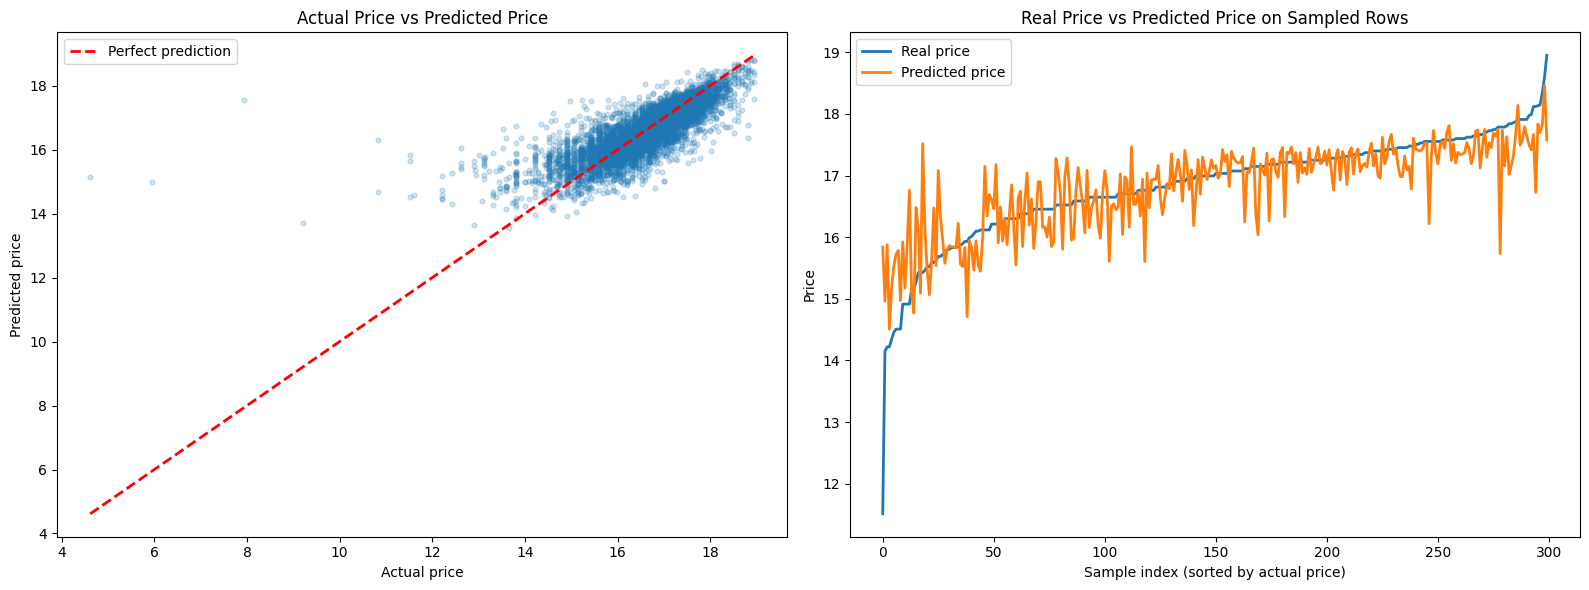

In [ ]:
if "final_prediction_df" not in globals():
    raise ValueError("Hãy chạy cell đánh giá cuối cùng trước để tạo final_prediction_df.")

scatter_sample_size = min(8000, len(final_prediction_df))
line_sample_size = min(300, len(final_prediction_df))

scatter_df = final_prediction_df.sample(scatter_sample_size, random_state=RANDOM_STATE)
line_df = (
    final_prediction_df
    .sample(line_sample_size, random_state=RANDOM_STATE)
    .sort_values("actual_price")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    scatter_df["actual_price"],
    scatter_df["predicted_price"],
    alpha=0.20,
    s=12,
    color="#1f77b4",
)
min_price = min(scatter_df["actual_price"].min(), scatter_df["predicted_price"].min())
max_price = max(scatter_df["actual_price"].max(), scatter_df["predicted_price"].max())
axes[0].plot([min_price, max_price], [min_price, max_price], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_title("Actual Price vs Predicted Price")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")
axes[0].legend()

axes[1].plot(line_df.index, line_df["actual_price"], label="Real price", linewidth=2)
axes[1].plot(line_df.index, line_df["predicted_price"], label="Predicted price", linewidth=2)
axes[1].set_title("Real Price vs Predicted Price on Sampled Rows")
axes[1].set_xlabel("Sample index (sorted by actual price)")
axes[1].set_ylabel("Price")
axes[1].legend()

plt.tight_layout()
plt.show()


## 18. Phân tích residual và độ lệch dự đoán

Nhóm biểu đồ này cho thấy sai số đang phân bố như thế nào.
Histogram của residual cho biết model hay overpredict hay underpredict, còn scatter `actual price vs absolute error` giúp xem vùng giá nào đang dự đoán khó hơn.


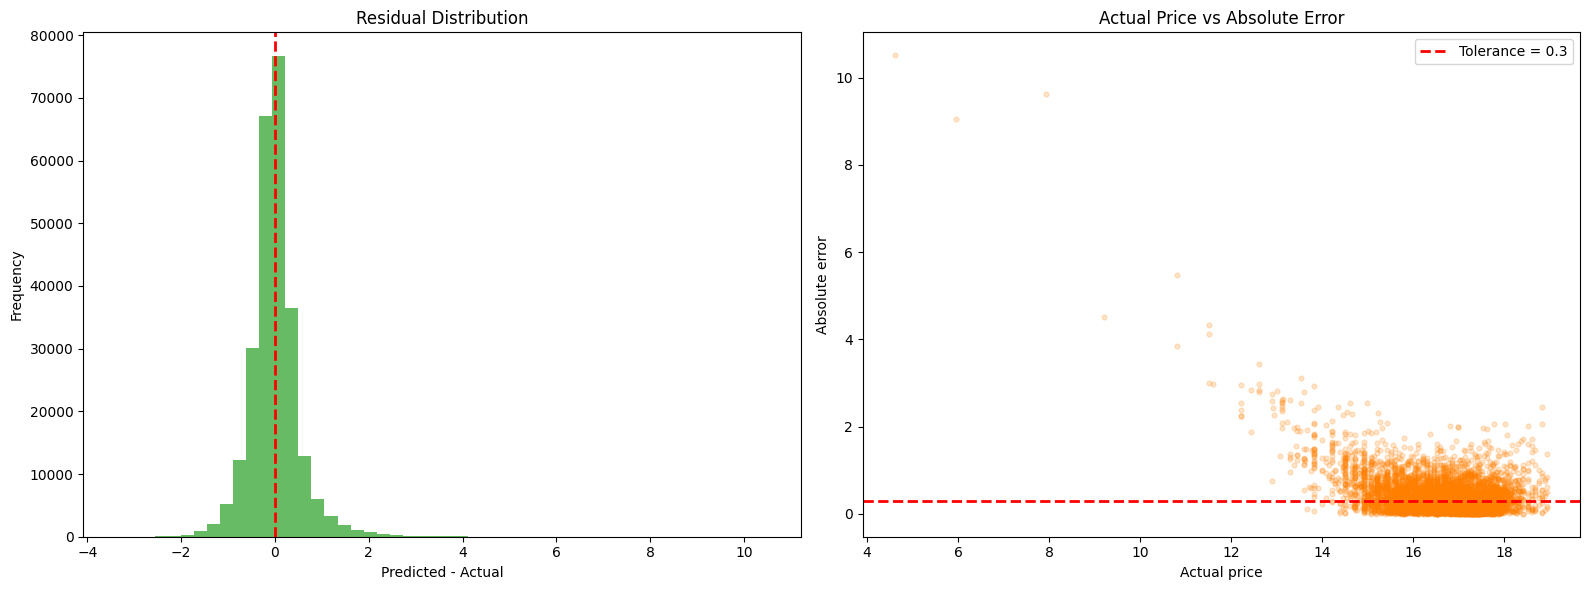

In [ ]:
if "final_prediction_df" not in globals():
    raise ValueError("Hãy chạy cell đánh giá cuối cùng trước để tạo final_prediction_df.")

residual_plot_df = final_prediction_df.copy()
residual_plot_df["residual"] = residual_plot_df["predicted_price"] - residual_plot_df["actual_price"]

scatter_error_sample_size = min(8000, len(residual_plot_df))
scatter_error_df = residual_plot_df.sample(scatter_error_sample_size, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(residual_plot_df["residual"], bins=50, color="#4daf4a", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Predicted - Actual")
axes[0].set_ylabel("Frequency")

axes[1].scatter(
    scatter_error_df["actual_price"],
    scatter_error_df["abs_error"],
    alpha=0.20,
    s=12,
    color="#ff7f00",
)
axes[1].axhline(ACCURACY_TOLERANCE, color="red", linestyle="--", linewidth=2, label=f"Tolerance = {ACCURACY_TOLERANCE}")
axes[1].set_title("Actual Price vs Absolute Error")
axes[1].set_xlabel("Actual price")
axes[1].set_ylabel("Absolute error")
axes[1].legend()

plt.tight_layout()
plt.show()
